# Linearity assumption checks 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from pathlib import Path
import math
from statsmodels.nonparametric.smoothers_lowess import lowess


## 1) Loading dataset


In [ ]:
data_path = Path("../data/raw/dataset_31_credit-g.arff")
raw, meta = arff.loadarff(str(data_path))

df = pd.DataFrame(raw)

for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].apply(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

df.head(), df.shape


(  checking_status  duration                  credit_history  \
 0              <0       6.0  critical/other existing credit   
 1        0<=X<200      48.0                   existing paid   
 2     no checking      12.0  critical/other existing credit   
 3              <0      42.0                   existing paid   
 4              <0      24.0              delayed previously   
 
                purpose  credit_amount    savings_status employment  \
 0             radio/tv         1169.0  no known savings        >=7   
 1             radio/tv         5951.0              <100     1<=X<4   
 2            education         2096.0              <100     4<=X<7   
 3  furniture/equipment         7882.0              <100     4<=X<7   
 4              new car         4870.0              <100     1<=X<4   
 
    installment_commitment     personal_status other_parties  ...  \
 0                     4.0         male single          none  ...   
 1                     2.0  female div/dep/mar  

## 2) Quick data overview


In [3]:
df.describe(include="all").T.head(30)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_status,1000,4,no checking,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
credit_history,1000,5,existing paid,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,radio/tv,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
savings_status,1000,5,<100,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment,1000,5,1<=X<4,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_commitment,1000.0,NaN,NaN,NaN,2.973,1.118715,1.0,2.0,3.0,4.0,4.0
personal_status,1000,4,male single,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_parties,1000,3,none,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
TARGET_COL = "class" if "class" in df.columns else df.columns[-1]
TARGET_COL


'class'

In [5]:
y_raw = df[TARGET_COL]
X_raw = df.drop(columns=[TARGET_COL])
y_raw.value_counts(dropna=False).head(20)


class
good    700
bad     300
Name: count, dtype: int64

In [ ]:
is_numeric_target = pd.api.types.is_numeric_dtype(y_raw)
n_unique = y_raw.nunique(dropna=True)

problem_type = None
if is_numeric_target and n_unique > 10:
    problem_type = "regression"
elif n_unique == 2:
    problem_type = "binary_classification"
else:
    problem_type = "classification"

problem_type, is_numeric_target, n_unique


('binary_classification', False, 2)

## 3) Identify numeric vs categorical features


In [11]:
numeric_cols = [c for c in X_raw.columns if pd.api.types.is_numeric_dtype(X_raw[c]) and c not in ["num_dependents"]]
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

len(numeric_cols), len(categorical_cols), numeric_cols[:10], categorical_cols[:10]


(6,
 14,
 ['duration',
  'credit_amount',
  'installment_commitment',
  'residence_since',
  'age',
  'existing_credits'],
 ['checking_status',
  'credit_history',
  'purpose',
  'savings_status',
  'employment',
  'personal_status',
  'other_parties',
  'property_magnitude',
  'other_payment_plans',
  'housing'])

## 4) Create the plots check for linearity




In [ ]:
def plot_regression_linearity(ax, df, x_col, y_col, max_points=5000):
    d = df[[x_col, y_col]].dropna()
    if len(d) > max_points:
        d = d.sample(max_points, random_state=0)

    x = d[x_col].astype(float).values
    y = d[y_col].astype(float).values

    ax.scatter(x, y, s=10)
    sm = lowess(y, x, frac=0.3, return_sorted=True)
    ax.plot(sm[:,0], sm[:,1], linewidth=2)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"Linearity check: {x_col} vs {y_col} (LOWESS)")

def plot_logit_linearity(ax, df, x_col, y_col, bins=10):
    d = df[[x_col, y_col]].dropna().copy()
    x = d[x_col].astype(float)
    y = d[y_col].astype(int)

    qbins = pd.qcut(x, q=min(bins, x.nunique()), duplicates="drop")
    grp = d.groupby(qbins, observed=True)

    x_mid = grp[x_col].mean()
    p = grp[y_col].mean()
    n = grp.size()

    eps = 0.5
    p_adj = (p*n + eps) / (n + 2*eps)
    log_odds = np.log(p_adj / (1 - p_adj))

    ax.scatter(x_mid, log_odds, s=30)
    sm = lowess(log_odds.values, x_mid.values, frac=0.6, return_sorted=True)
    ax.plot(sm[:,0], sm[:,1], linewidth=2)
    ax.set_xlabel(x_col)
    ax.set_ylabel("Empirical log-odds (binned)")
    ax.set_title(f"Linearity-in-the-logit check: {x_col} vs log-odds({y_col})")


work = df.copy()


In [13]:
if problem_type == "binary_classification":
    # map classes to 0/1 (keep a record)
    classes = sorted(y_raw.dropna().unique().tolist())
    class_to_int = {classes[0]: 0, classes[1]: 1}
    work[TARGET_COL] = work[TARGET_COL].map(class_to_int).astype(int)
    class_to_int


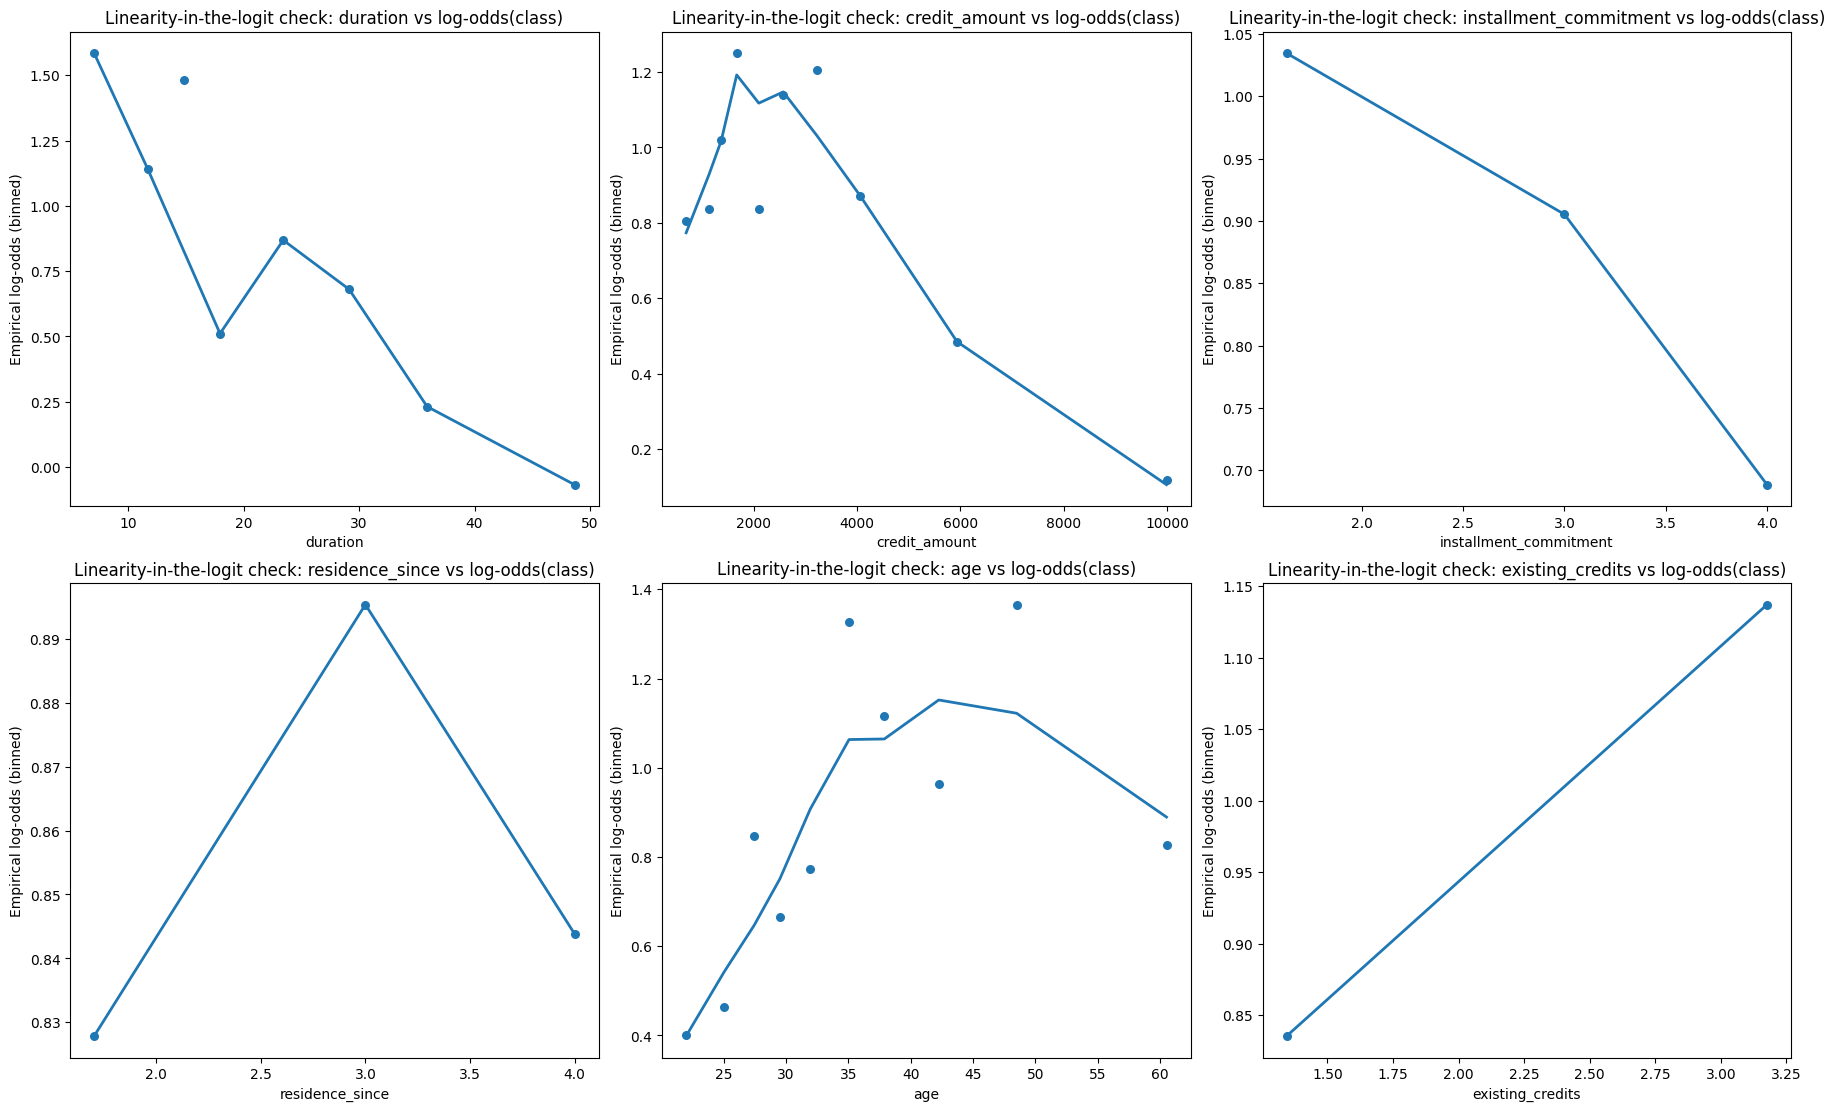

In [ ]:
if len(numeric_cols) == 0:
    print("No numeric features detected. Skip to Part C (model-based diagnostics with encoded categoricals).")
else:
    n_plots = len(numeric_cols)
    n_cols = min(3, max(1, n_plots)) 
    n_rows = math.ceil(n_plots / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5.5*n_rows), constrained_layout=True)
    
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        if problem_type == "regression":
            plot_regression_linearity(ax, work, col, TARGET_COL)
        elif problem_type == "binary_classification":
            plot_logit_linearity(ax, work, col, TARGET_COL, bins=10)
        else:
            print("Non-binary classification detected; consider one-vs-rest logits or use model-based diagnostics in Part C.")
    
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.show()
